# O1 minimum-split policy analytics

This notebook compares fixed and three-stage `min_samples_split` policies over five benchmark seeds and five SMAC seeds. Lower regret and lower rank are better. Confidence bands are pointwise 95% Student-t intervals across SMAC seeds.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import t

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 110, 'savefig.bbox': 'tight'})

RELATIVE_EXPERIMENT = Path('experiments/synthaticBench/o1_deterministic/split_policies/01_initial')
candidates = [Path.cwd() / RELATIVE_EXPERIMENT, Path.cwd()]
EXPERIMENT = next((p.resolve() for p in candidates if (p / 'o1_split_policy_runner.py').exists()), None)
if EXPERIMENT is None:
    raise FileNotFoundError('Run from the repository root or the split_policies/01_initial directory.')
OUTPUT = EXPERIMENT / 'smac_output'
BENCHMARK_SEEDS = tuple(range(40, 45))
SMAC_SEEDS = tuple(range(5))
SPLIT_VALUES = (1, 2, 3)
STAGE_SWITCHES = (200, 500)
STAGE_LABELS = ('Stage 1 (1-200)', 'Stage 2 (201-500)', 'Stage 3 (501-1000)')
N_TRIALS = 1000
N_POLICIES = 27
EXPECTED_RUNS = len(BENCHMARK_SEEDS) * len(SMAC_SEEDS) * N_POLICIES
FIXED_POLICIES = [f'fixed_split_{value}' for value in SPLIT_VALUES]
print(f'Experiment: {EXPERIMENT}')


Experiment: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o1_deterministic/split_policies/01_initial


## Load and validate all trajectories

In [2]:
rows = []
curves = {}
for path in sorted(OUTPUT.rglob('trajectory.json')):
    data = json.loads(path.read_text())
    spec = data['policy_spec']
    if data['policy_type'] == 'fixed':
        stage_splits = (int(spec['fixed_split']),) * 3
    else:
        stage_splits = tuple(map(int, spec['stage_splits']))
    best_regret = np.asarray(data['best_regret'], dtype=float)
    key = (int(data['benchmark_seed']), int(data['smac_seed']), data['policy'])
    if key in curves:
        raise ValueError(f'Duplicate trajectory: {key}')
    curves[key] = best_regret
    rows.append({
        'benchmark_seed': key[0], 'smac_seed': key[1], 'policy': key[2],
        'policy_family': data['policy_family'], 'policy_type': data['policy_type'],
        'is_adaptive': data['policy_type'] != 'fixed',
        's1': stage_splits[0], 's2': stage_splits[1], 's3': stage_splits[2],
        'final_regret': float(best_regret[-1]),
        'mean_regret': float(best_regret.mean()),
        'log_auc': float(np.log10(np.maximum(best_regret, 1e-300)).mean()),
        'n_trials': int(data['n_trials']),
        'max_depth': int(data['max_depth']),
        'min_samples_leaf': int(data['min_samples_leaf']),
        'random_design_probability': float(data['random_design_probability']),
        'path': path,
    })

results = pd.DataFrame(rows)
if results.empty:
    raise FileNotFoundError(f'No trajectories found below {OUTPUT}')
assert len(results) == EXPECTED_RUNS, f'Expected {EXPECTED_RUNS} trajectories, found {len(results)}.'
assert tuple(sorted(results.benchmark_seed.unique())) == BENCHMARK_SEEDS
assert tuple(sorted(results.smac_seed.unique())) == SMAC_SEEDS
assert results.policy.nunique() == N_POLICIES
assert results.groupby(['benchmark_seed', 'smac_seed']).size().eq(N_POLICIES).all()
assert results.groupby('policy').size().eq(len(BENCHMARK_SEEDS) * len(SMAC_SEEDS)).all()
assert results.n_trials.eq(N_TRIALS).all()
assert results.max_depth.eq(2000).all()
assert results.min_samples_leaf.eq(1).all()
assert results.random_design_probability.eq(0.0).all()
print(f'Loaded and validated {len(results):,} trajectories for {results.policy.nunique()} policies.')
display(results.groupby('policy_family').agg(policies=('policy', 'nunique'), trajectories=('policy', 'size')))


Loaded and validated 675 trajectories for 27 policies.


,policies,trajectories
policy_family,,
fixed,3,75
three_stage,24,600


## Fixed split values

These figures isolate the three fixed controls before comparing adaptive schedules.

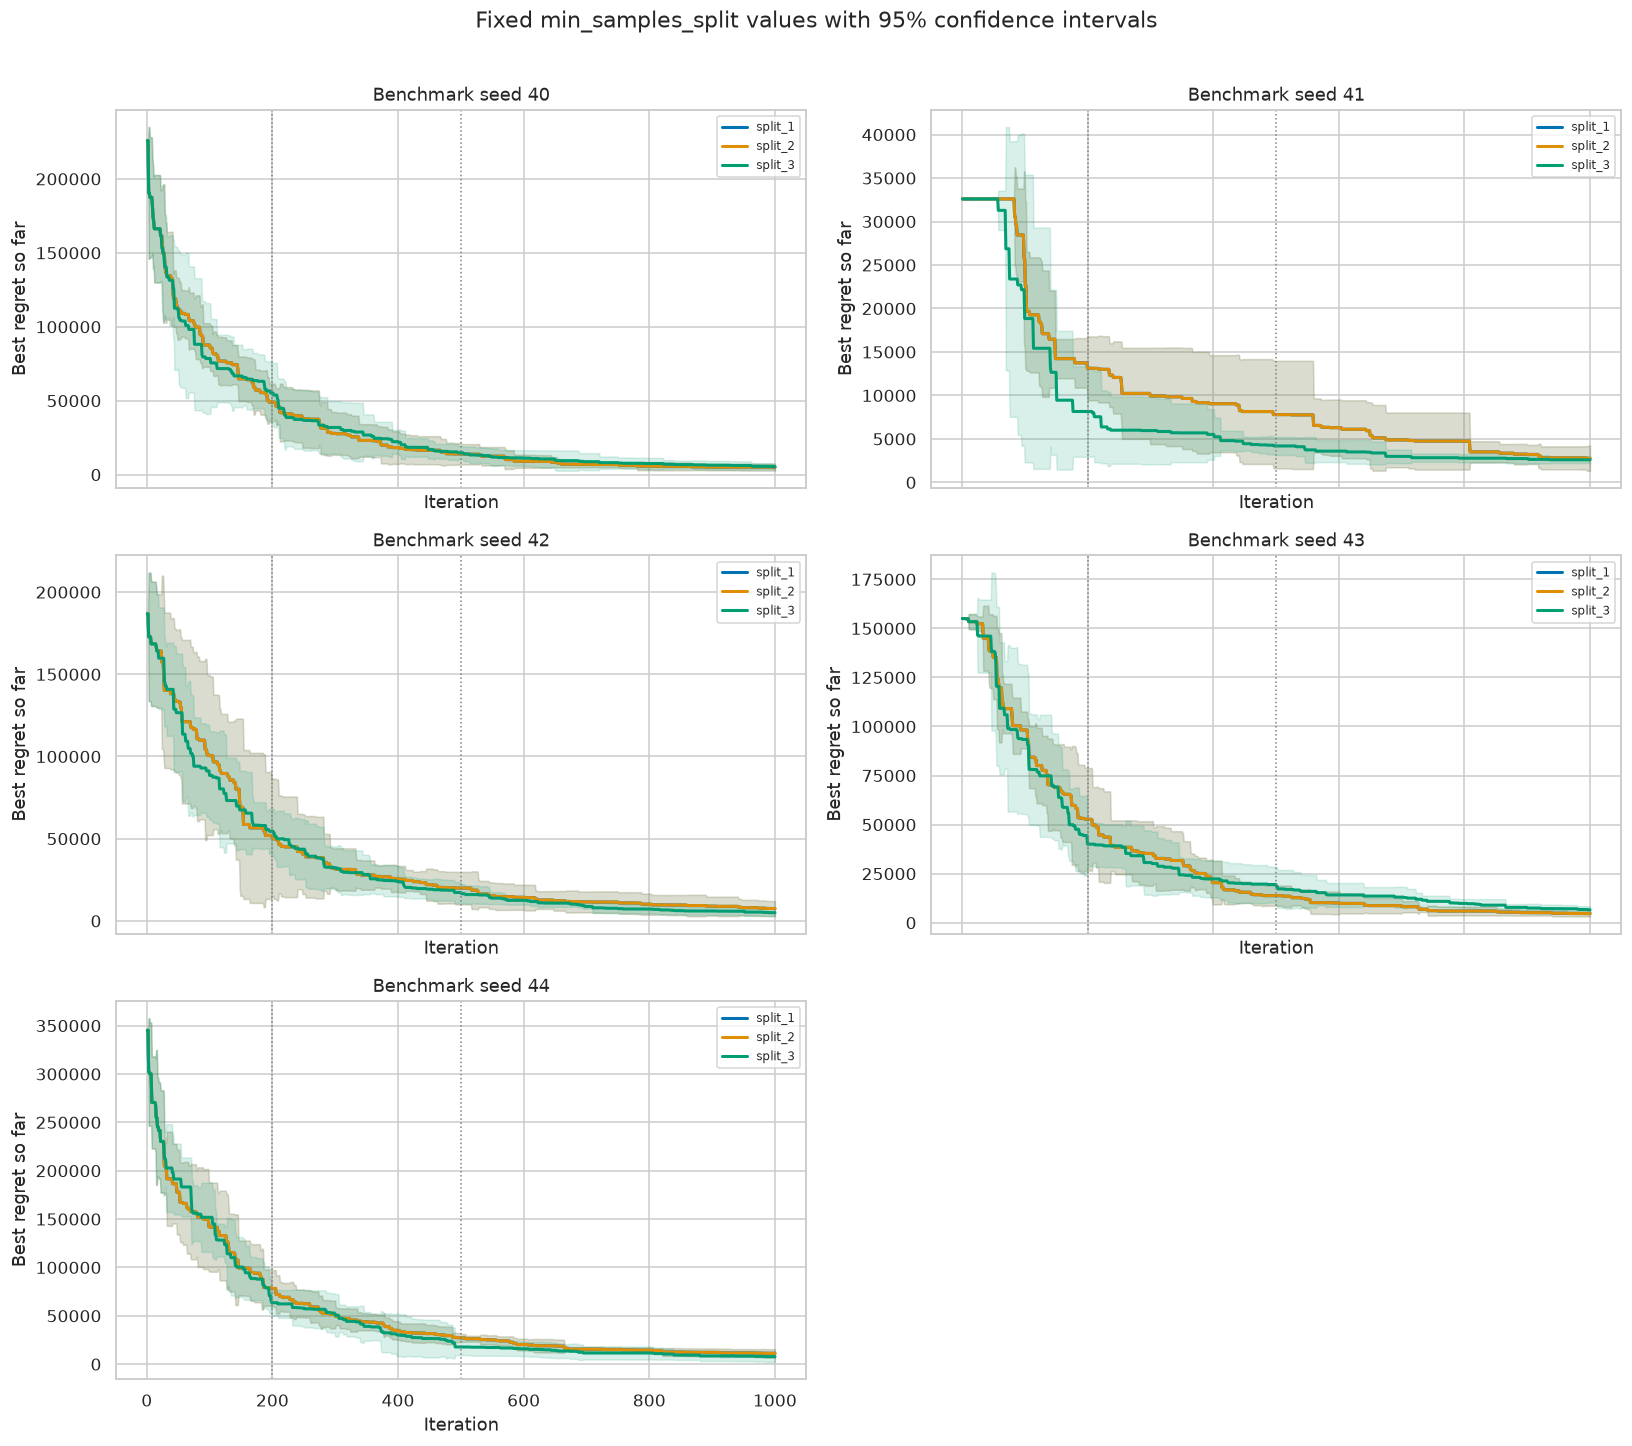

In [3]:
def mean_ci(matrix, confidence=0.95):
    matrix = np.asarray(matrix, dtype=float)
    mean = matrix.mean(axis=0)
    sem = matrix.std(axis=0, ddof=1) / np.sqrt(matrix.shape[0])
    half = t.ppf((1 + confidence) / 2, matrix.shape[0] - 1) * sem
    return mean, mean - half, mean + half

fig, axes = plt.subplots(3, 2, figsize=(15, 13), sharex=True)
axes = axes.ravel()
fixed_palette = dict(zip(FIXED_POLICIES, sns.color_palette('colorblind', 3)))
for ax, benchmark_seed in zip(axes, BENCHMARK_SEEDS):
    for policy in FIXED_POLICIES:
        matrix = np.stack([curves[(benchmark_seed, seed, policy)] for seed in SMAC_SEEDS])
        mean, lower, upper = mean_ci(matrix)
        iterations = np.arange(1, N_TRIALS + 1)
        color = fixed_palette[policy]
        ax.plot(iterations, mean, color=color, lw=2, label=policy.replace('fixed_', ''))
        ax.fill_between(iterations, lower, upper, color=color, alpha=.15)
    ax.axvline(200, color='0.5', lw=1, ls=':')
    ax.axvline(500, color='0.5', lw=1, ls=':')
    ax.set_title(f'Benchmark seed {benchmark_seed}')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Best regret so far')
    ax.legend(fontsize=8)
axes[-1].axis('off')
fig.suptitle('Fixed min_samples_split values with 95% confidence intervals', y=1.01)
fig.tight_layout()
plt.show()


## Policy rankings and best-so-far curves

Policies are ranked independently on each benchmark seed before ranks are averaged, preventing landscapes with larger regret scales from dominating.

,policy,policy_family,policy_type,is_adaptive,mean_landscape_rank,worst_landscape_rank,mean_final_regret,mean_log_auc
4,split_stages_1_1_3,three_stage,three_stage,True,7.70,16,5049.2,4.1915
7,split_stages_1_2_3,three_stage,three_stage,True,7.70,16,5049.2,4.1915
13,split_stages_2_1_3,three_stage,three_stage,True,7.70,16,5049.2,4.1915
15,split_stages_2_2_3,three_stage,three_stage,True,7.70,16,5049.2,4.1915
25,split_stages_3_3_1,three_stage,three_stage,True,8.10,20,5198.9,4.1785
26,split_stages_3_3_2,three_stage,three_stage,True,8.10,20,5198.9,4.1785
2,fixed_split_3,fixed,fixed,False,12.60,25,5452.6,4.1875
19,split_stages_3_1_1,three_stage,three_stage,True,12.90,22,5504.1,4.1624
20,split_stages_3_1_2,three_stage,three_stage,True,12.90,22,5504.1,4.1624
22,split_stages_3_2_1,three_stage,three_stage,True,12.90,22,5504.1,4.1624


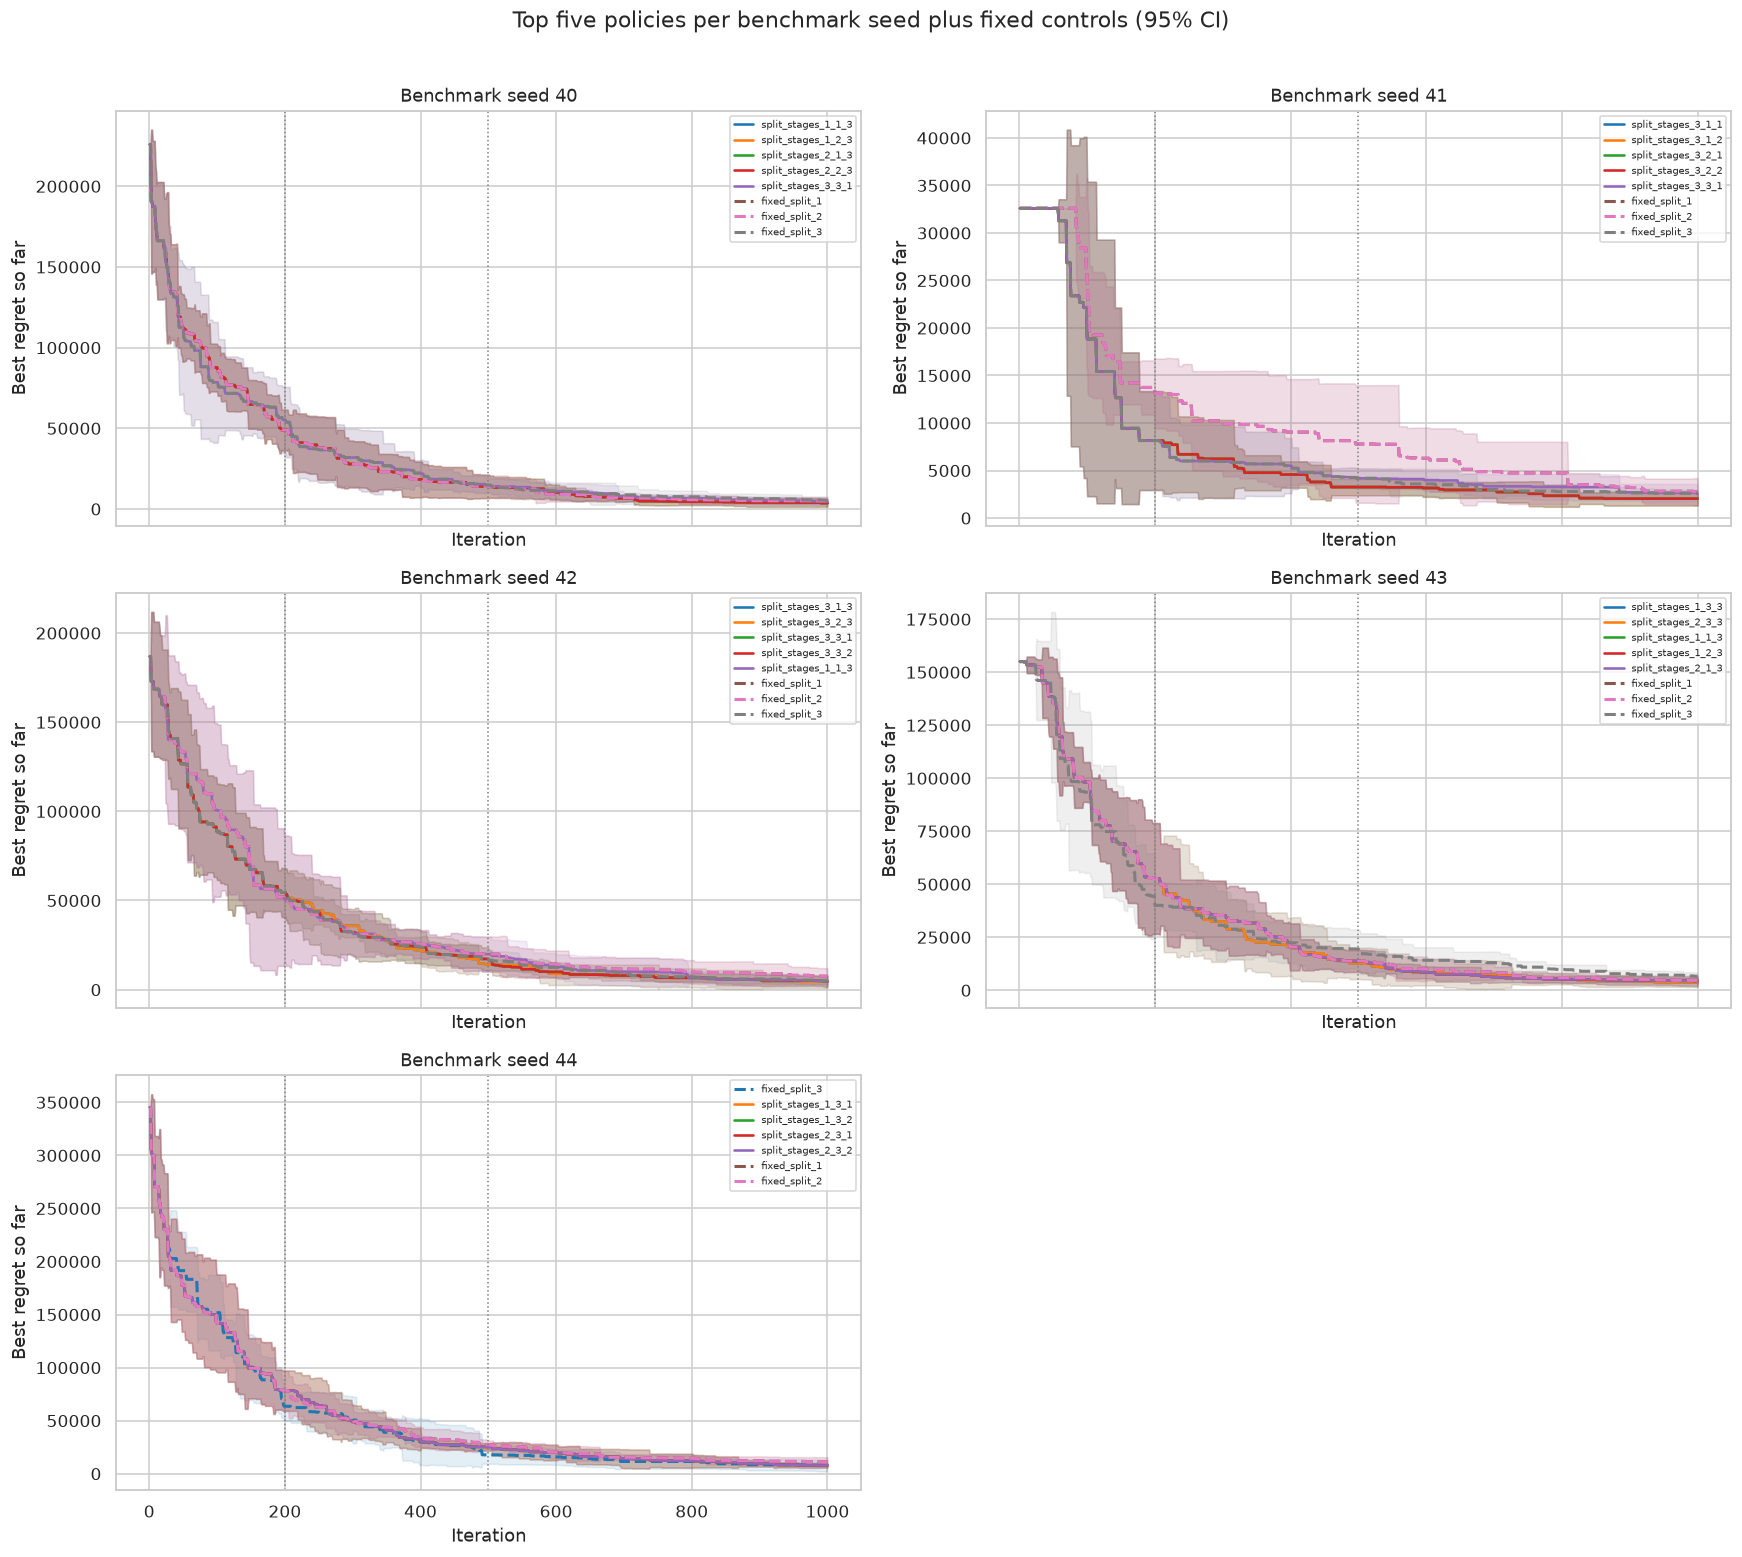

In [4]:
landscape_policy = (results.groupby(['benchmark_seed', 'policy', 'policy_family', 'policy_type', 'is_adaptive'], as_index=False)
                    .agg(mean_final_regret=('final_regret', 'mean'),
                         std_final_regret=('final_regret', 'std'),
                         mean_log_auc=('log_auc', 'mean')))
landscape_policy['landscape_rank'] = landscape_policy.groupby('benchmark_seed')['mean_final_regret'].rank(method='average')
policy_summary = (landscape_policy.groupby(['policy', 'policy_family', 'policy_type', 'is_adaptive'], as_index=False)
                  .agg(mean_landscape_rank=('landscape_rank', 'mean'),
                       worst_landscape_rank=('landscape_rank', 'max'),
                       mean_final_regret=('mean_final_regret', 'mean'),
                       mean_log_auc=('mean_log_auc', 'mean'))
                  .sort_values(['mean_landscape_rank', 'worst_landscape_rank', 'policy']))
display(policy_summary.head(15).style.format({
    'mean_landscape_rank': '{:.2f}', 'worst_landscape_rank': '{:.0f}',
    'mean_final_regret': '{:.5g}', 'mean_log_auc': '{:.4f}',
}))

fig, axes = plt.subplots(3, 2, figsize=(16, 14), sharex=True)
axes = axes.ravel()
for ax, benchmark_seed in zip(axes, BENCHMARK_SEEDS):
    top = (landscape_policy.query('benchmark_seed == @benchmark_seed')
           .nsmallest(5, 'mean_final_regret').policy.tolist())
    selected = list(dict.fromkeys(top + FIXED_POLICIES))
    colors = dict(zip(selected, sns.color_palette('tab10', len(selected))))
    for policy in selected:
        matrix = np.stack([curves[(benchmark_seed, seed, policy)] for seed in SMAC_SEEDS])
        mean, lower, upper = mean_ci(matrix)
        iterations = np.arange(1, N_TRIALS + 1)
        is_fixed = policy in FIXED_POLICIES
        ax.plot(iterations, mean, color=colors[policy], lw=2 if is_fixed else 1.7,
                ls='--' if is_fixed else '-', label=policy)
        ax.fill_between(iterations, lower, upper, color=colors[policy], alpha=.12)
    ax.axvline(200, color='0.5', lw=1, ls=':')
    ax.axvline(500, color='0.5', lw=1, ls=':')
    ax.set_title(f'Benchmark seed {benchmark_seed}')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Best regret so far')
    ax.legend(fontsize=6.5)
axes[-1].axis('off')
fig.suptitle('Top five policies per benchmark seed plus fixed controls (95% CI)', y=1.01)
fig.tight_layout()
plt.show()


## Stage-wise split effects

Each trajectory is ranked against all 27 policies for the same benchmark seed and SMAC seed. The heatmaps show the complete 3×3×3 policy cube; fixed policies occupy the diagonal constant schedules.

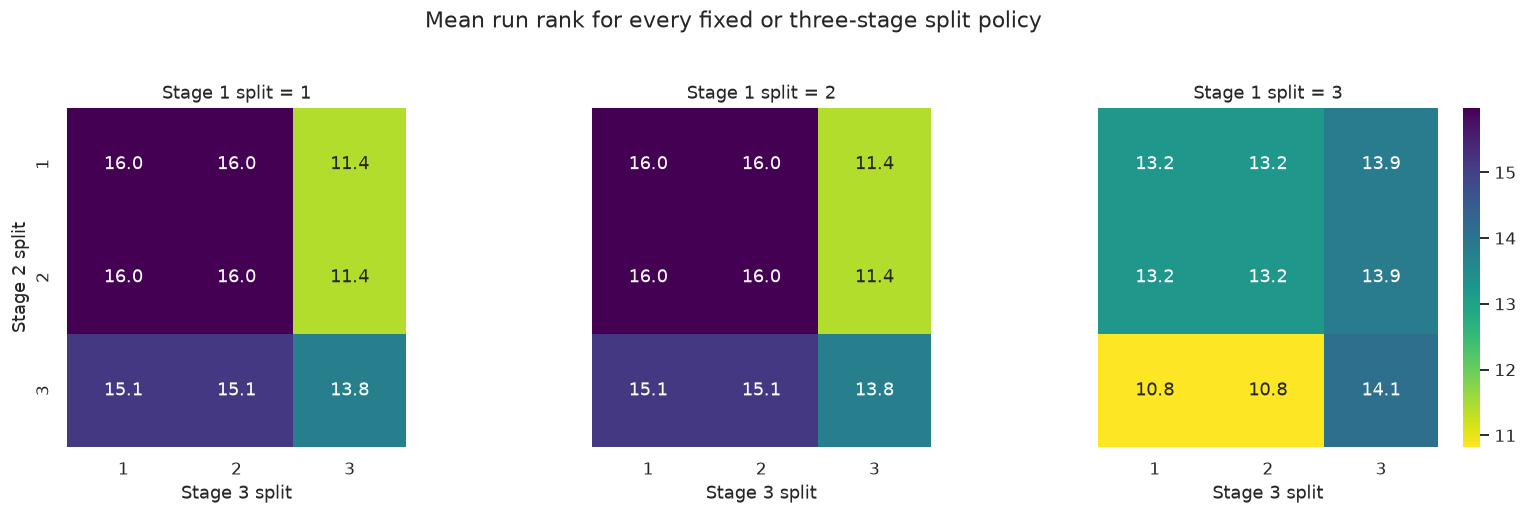

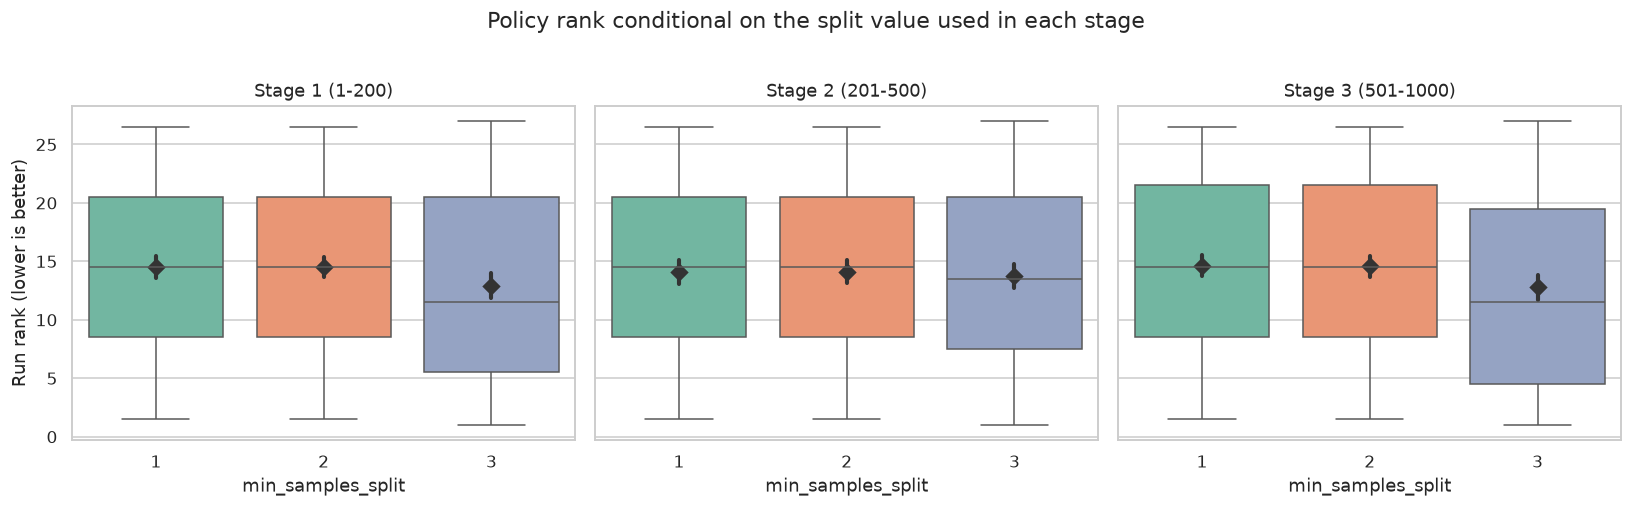

In [5]:
ranked = results.copy()
ranked['run_rank'] = ranked.groupby(['benchmark_seed', 'smac_seed'])['final_regret'].rank(method='average')
policy_stage_map = ranked[['policy', 's1', 's2', 's3']].drop_duplicates()
policy_cube = (ranked.groupby(['policy', 's1', 's2', 's3'], as_index=False)
               .agg(mean_run_rank=('run_rank', 'mean'), mean_final_regret=('final_regret', 'mean')))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
vmin, vmax = policy_cube.mean_run_rank.min(), policy_cube.mean_run_rank.max()
for ax, first_split in zip(axes, SPLIT_VALUES):
    matrix = (policy_cube.query('s1 == @first_split').pivot(index='s2', columns='s3', values='mean_run_rank')
              .reindex(index=SPLIT_VALUES, columns=SPLIT_VALUES))
    sns.heatmap(matrix, annot=True, fmt='.1f', cmap='viridis_r', vmin=vmin, vmax=vmax,
                square=True, cbar=ax is axes[-1], ax=ax)
    ax.set_title(f'Stage 1 split = {first_split}')
    ax.set_xlabel('Stage 3 split')
    ax.set_ylabel('Stage 2 split' if ax is axes[0] else '')
fig.suptitle('Mean run rank for every fixed or three-stage split policy', y=1.03)
fig.tight_layout()
plt.show()

stage_long = ranked.melt(
    id_vars=['benchmark_seed', 'smac_seed', 'policy', 'run_rank', 'final_regret'],
    value_vars=['s1', 's2', 's3'], var_name='stage_code', value_name='split_value')
stage_names = dict(zip(('s1', 's2', 's3'), STAGE_LABELS))
stage_long['stage'] = pd.Categorical(stage_long.stage_code.map(stage_names), categories=STAGE_LABELS, ordered=True)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, stage in zip(axes, STAGE_LABELS):
    subset = stage_long[stage_long.stage == stage]
    sns.boxplot(data=subset, x='split_value', y='run_rank', hue='split_value',
                order=SPLIT_VALUES, palette='Set2', showfliers=False, legend=False, ax=ax)
    sns.pointplot(data=subset, x='split_value', y='run_rank', order=SPLIT_VALUES,
                  color='0.2', errorbar=('ci', 95), markers='D', linestyles='none', ax=ax)
    ax.set_title(stage)
    ax.set_xlabel('min_samples_split')
    ax.set_ylabel('Run rank (lower is better)' if ax is axes[0] else '')
fig.suptitle('Policy rank conditional on the split value used in each stage', y=1.02)
fig.tight_layout()
plt.show()


## Split choices among run-level top policies

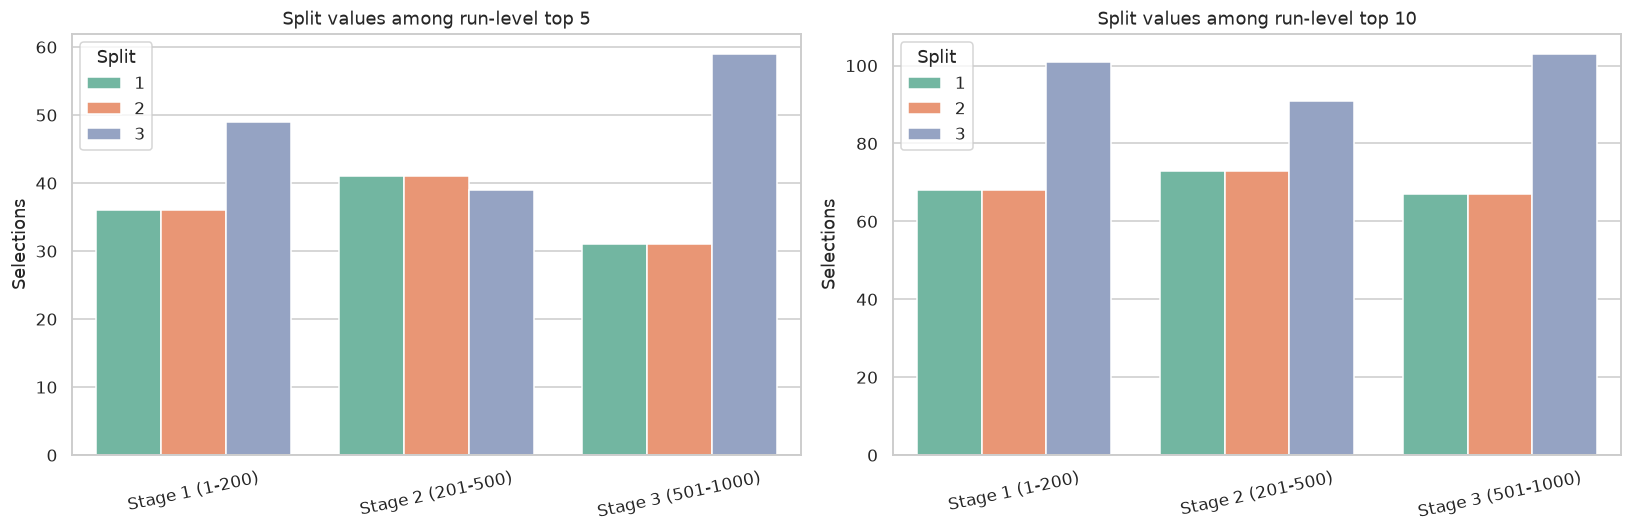

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)
for ax, top_n in zip(axes, (5, 10)):
    subset = stage_long.query('run_rank <= @top_n')
    counts = (subset.groupby(['stage', 'split_value'], observed=False).size()
              .rename('count').reset_index())
    sns.barplot(data=counts, x='stage', y='count', hue='split_value',
                hue_order=SPLIT_VALUES, palette='Set2', ax=ax)
    ax.set_title(f'Split values among run-level top {top_n}')
    ax.set_xlabel('')
    ax.set_ylabel('Selections')
    ax.tick_params(axis='x', rotation=12)
    ax.legend(title='Split')
fig.tight_layout()
plt.show()


## Leave-one-benchmark-seed-out validation

For every held-out benchmark seed, the best adaptive policy and best fixed split are selected by mean rank on the other four benchmark seeds, then compared on five paired SMAC seeds.

,held_out,adaptive_policy,fixed_policy
0,40,split_stages_3_3_1,fixed_split_3
1,41,split_stages_1_1_3,fixed_split_3
2,42,split_stages_1_1_3,fixed_split_3
3,43,split_stages_3_3_1,fixed_split_3
4,44,split_stages_1_1_3,fixed_split_3


,held_out,strategy,mean_final_regret,std,n,ci95
0,40,Adaptive,4490.623501,1405.834105,5,1745.573595
1,40,Fixed,5365.143849,1422.693351,5,1766.507114
2,41,Adaptive,2736.569937,682.484851,5,847.416869
3,41,Fixed,2597.692675,300.939221,5,373.665397
4,42,Adaptive,4807.027322,2332.309970,5,2895.945322
5,42,Fixed,4979.878569,1810.949539,5,2248.590845
6,43,Adaptive,6344.253723,2564.149785,5,3183.812474
7,43,Fixed,6587.832161,1361.316893,5,1690.298176
8,44,Adaptive,9666.505380,6238.617903,5,7746.267249
9,44,Fixed,7732.493692,4441.506136,5,5514.858266


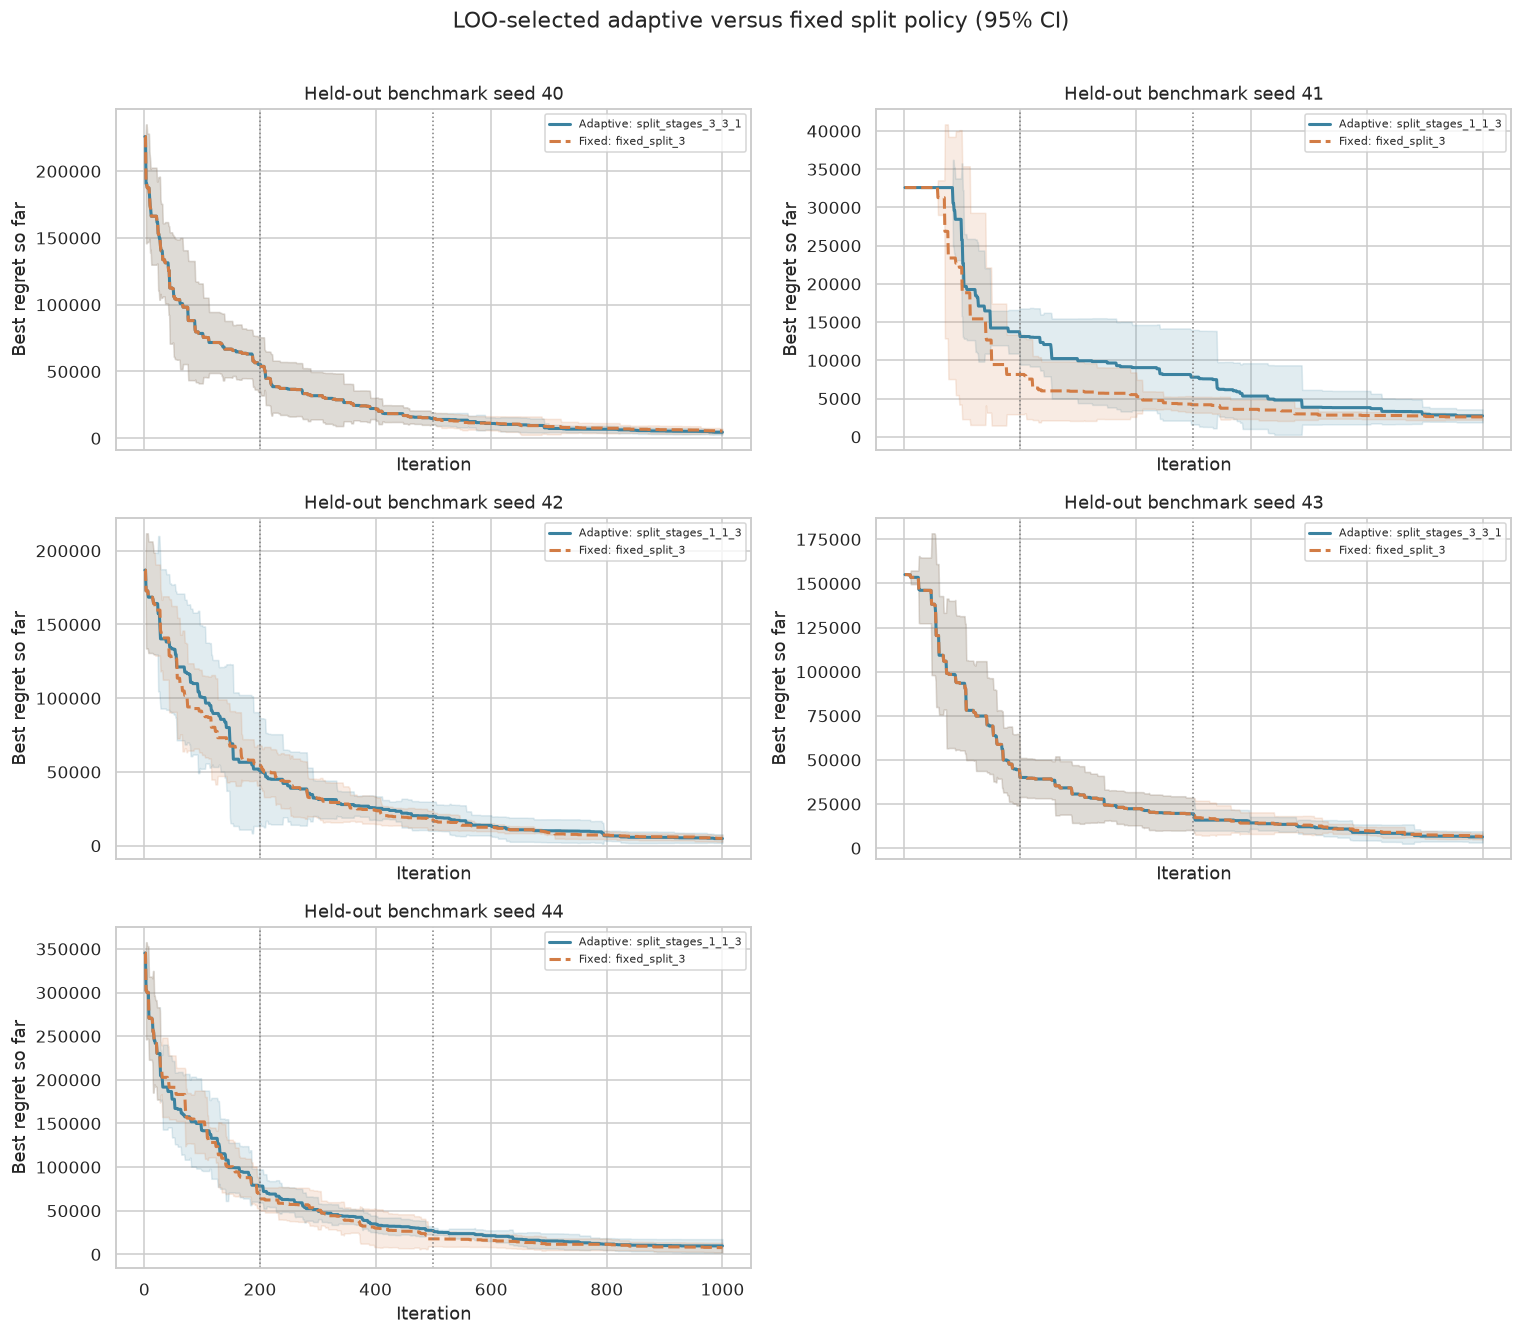

/tmp/io632776/login23-4_278471/ipykernel_289277/4130063421.py:67: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:0.2'` for the same effect.

  sns.stripplot(data=loo, x='held_out', y='final_regret', hue='strategy', dodge=True,


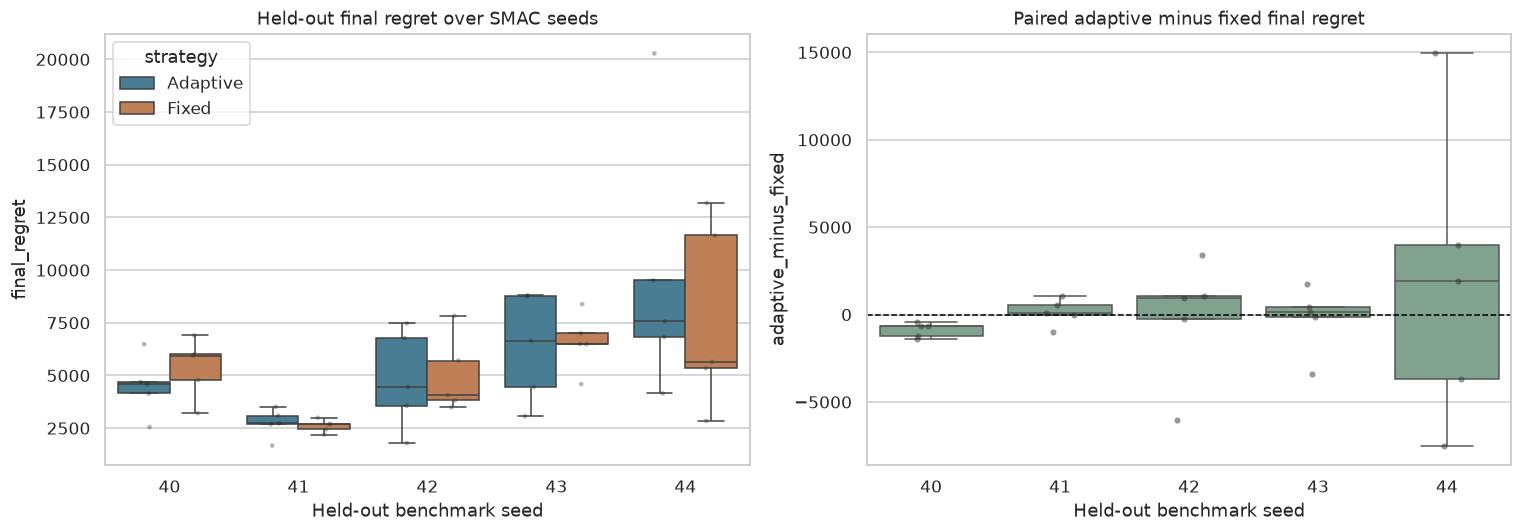

In [7]:
loo_choices = {}
loo_rows = []
for held_out in BENCHMARK_SEEDS:
    training = landscape_policy.query('benchmark_seed != @held_out').copy()
    training['training_rank'] = training.groupby('benchmark_seed')['mean_final_regret'].rank(method='average')
    aggregate = (training.groupby(['policy', 'is_adaptive'], as_index=False)
                 .agg(mean_training_rank=('training_rank', 'mean'),
                      mean_training_regret=('mean_final_regret', 'mean')))
    adaptive = (aggregate.query('is_adaptive')
                .sort_values(['mean_training_rank', 'mean_training_regret', 'policy']).iloc[0])
    fixed = (aggregate.query('not is_adaptive')
             .sort_values(['mean_training_rank', 'mean_training_regret', 'policy']).iloc[0])
    loo_choices[held_out] = {'Adaptive': adaptive.policy, 'Fixed': fixed.policy}
    held = results.query('benchmark_seed == @held_out')
    for smac_seed in SMAC_SEEDS:
        seed_results = held.query('smac_seed == @smac_seed').set_index('policy')
        adaptive_value = float(seed_results.loc[adaptive.policy, 'final_regret'])
        fixed_value = float(seed_results.loc[fixed.policy, 'final_regret'])
        loo_rows.extend([
            {'held_out': held_out, 'smac_seed': smac_seed, 'strategy': 'Adaptive',
             'policy': adaptive.policy, 'final_regret': adaptive_value,
             'adaptive_minus_fixed': adaptive_value - fixed_value},
            {'held_out': held_out, 'smac_seed': smac_seed, 'strategy': 'Fixed',
             'policy': fixed.policy, 'final_regret': fixed_value,
             'adaptive_minus_fixed': adaptive_value - fixed_value},
        ])
loo = pd.DataFrame(loo_rows)
display(pd.DataFrame([
    {'held_out': held_out, 'adaptive_policy': choices['Adaptive'], 'fixed_policy': choices['Fixed']}
    for held_out, choices in loo_choices.items()
]))

summary = (loo.groupby(['held_out', 'strategy'], as_index=False)
           .agg(mean_final_regret=('final_regret', 'mean'),
                std=('final_regret', 'std'), n=('final_regret', 'size')))
summary['ci95'] = t.ppf(.975, summary.n - 1) * summary['std'] / np.sqrt(summary.n)
display(summary)

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
axes = axes.ravel()
loo_colors = {'Adaptive': '#3b82a0', 'Fixed': '#d27c45'}
for ax, held_out in zip(axes, BENCHMARK_SEEDS):
    for strategy in ('Adaptive', 'Fixed'):
        policy = loo_choices[held_out][strategy]
        matrix = np.stack([curves[(held_out, seed, policy)] for seed in SMAC_SEEDS])
        mean, lower, upper = mean_ci(matrix)
        iterations = np.arange(1, N_TRIALS + 1)
        color = loo_colors[strategy]
        ax.plot(iterations, mean, color=color, lw=2, ls='-' if strategy == 'Adaptive' else '--',
                label=f'{strategy}: {policy}')
        ax.fill_between(iterations, lower, upper, color=color, alpha=.15)
    ax.axvline(200, color='0.5', lw=1, ls=':')
    ax.axvline(500, color='0.5', lw=1, ls=':')
    ax.set_title(f'Held-out benchmark seed {held_out}')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Best regret so far')
    ax.legend(fontsize=7)
axes[-1].axis('off')
fig.suptitle('LOO-selected adaptive versus fixed split policy (95% CI)', y=1.01)
fig.tight_layout()
plt.show()

paired = loo.query("strategy == 'Adaptive'").copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=loo, x='held_out', y='final_regret', hue='strategy', palette=loo_colors,
            showfliers=False, ax=axes[0])
sns.stripplot(data=loo, x='held_out', y='final_regret', hue='strategy', dodge=True,
              color='0.2', alpha=.35, size=3, ax=axes[0], legend=False)
sns.boxplot(data=paired, x='held_out', y='adaptive_minus_fixed', color='#7ba88d',
            showfliers=False, ax=axes[1])
sns.stripplot(data=paired, x='held_out', y='adaptive_minus_fixed', color='0.2',
              alpha=.5, size=4, jitter=.12, ax=axes[1])
axes[1].axhline(0, color='black', lw=1, ls='--')
axes[0].set_title('Held-out final regret over SMAC seeds')
axes[1].set_title('Paired adaptive minus fixed final regret')
axes[0].set_xlabel('Held-out benchmark seed')
axes[1].set_xlabel('Held-out benchmark seed')
fig.tight_layout()
plt.show()
